In [ ]:
### Import libraries

### Bring in pandas to work with tabular data
import pandas as pd

### Libraries for visualization
import holoviews as hv
import hvplot.pandas
import hvplot

### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt

### common statistical plots for tabular data
import seaborn as sns

### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

### get r2 and p value
import numpy as np

In [ ]:
### install library not in environment
! pip install statsmodels

### import library
import statsmodels.api as sm

In [4]:
### Make url data for data
ncei_url = ('https://www.ncei.noaa.gov/access/services/da'
            'ta/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00308721'
            '&startDate=1995-12-12&endDate=2025-12-31&units=standard')
### See url
ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00308721&startDate=1995-12-12&endDate=2025-12-31&units=standard'

In [5]:
### get the data using the URL
newyork_temp_df = pd.read_csv(
    ncei_url,

    ### tells python which column to use as the index
    index_col = 'DATE',

    ### tells python to treat values in DATE as dates
    parse_dates = True,

    ### tells python what the na values are
    na_values = ['NaN']
)

### See Long Island, New York temp df
newyork_temp_df


,STATION,TOBS
DATE,,
1995-12-12,USC00308721,16.0
1995-12-13,USC00308721,16.0
1995-12-14,USC00308721,22.0
1995-12-15,USC00308721,31.0
1995-12-16,USC00308721,NaN
...,...,...
2025-12-27,USC00308721,26.0
2025-12-28,USC00308721,14.0
2025-12-29,USC00308721,44.0


In [12]:
### save the climate data as csv
newyork_temp_df.to_csv('newyork_temp_data.csv')

In [ ]:
### wrangle the data
newyork_temp_only_df = newyork_temp_df[['TOBS']]

### open temp only dataframe
newyork_temp_only_df

,TOBS
DATE,
1995-12-12,16.0
1995-12-13,16.0
1995-12-14,22.0
1995-12-15,31.0
1995-12-16,NaN
...,...
2025-12-27,26.0
2025-12-28,14.0
2025-12-29,44.0


In [ ]:
### Verify units and give more detailed column name

### double check the units are degrees F
newyork_temp_only_df['TOBS'].agg(['min', 'max'])

### change TOBS column name to clarify units
ny_temp_units_df = newyork_temp_only_df.rename(columns={
    'TOBS': 'temp_f',
})

### open temp f dataframe
ny_temp_units_df

,temp_f
DATE,
1995-12-12,16.0
1995-12-13,16.0
1995-12-14,22.0
1995-12-15,31.0
1995-12-16,NaN
...,...
2025-12-27,26.0
2025-12-28,14.0
2025-12-29,44.0


In [10]:
### Convert units

### create function to convert F to C
def convert_f_to_c(temperature_f):
    """Convert temperature to Celsius"""
    return (temperature_f-32)*5/9

### apply function
ny_temp_units_df['temp_c']=(
    ny_temp_units_df['temp_f'].apply(convert_f_to_c)
)

### open dataframe
ny_temp_units_df

,temp_f,temp_c
DATE,,
1995-12-12,16.0,-8.888889
1995-12-13,16.0,-8.888889
1995-12-14,22.0,-5.555556
1995-12-15,31.0,-0.555556
1995-12-16,NaN,NaN
...,...,...
2025-12-27,26.0,-3.333333
2025-12-28,14.0,-10.000000
2025-12-29,44.0,6.666667


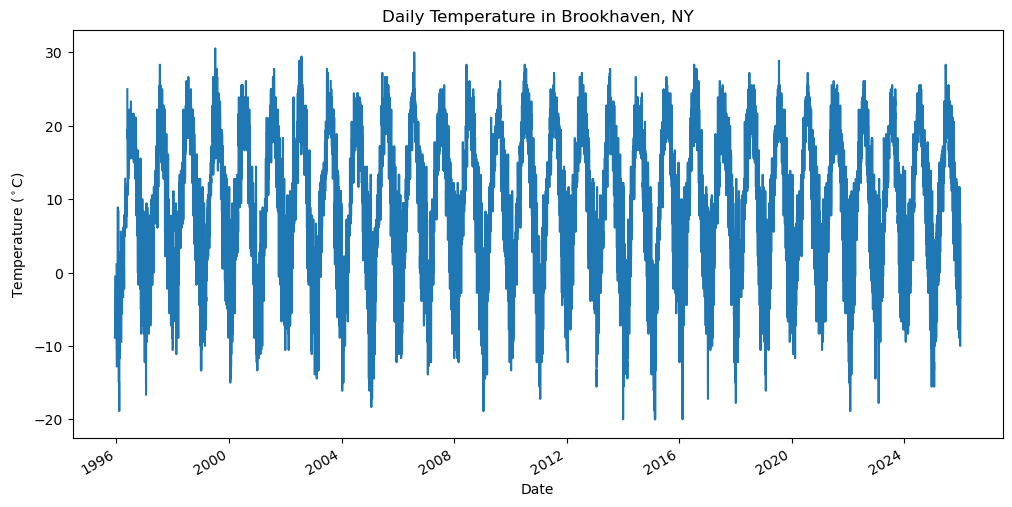

In [13]:
### plot the data

### create no legend object that is the daily temp plot
no_legend = ny_temp_units_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Brookhaven, NY',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize= (12,6))

### call the no legend object and tell it to remove the legend
no_legend.legend().remove()


In [ ]:
### create new dataframe and resample data to show mean annual temperatures and create graph with better resolution
ny_ann_temp_df = (
    ny_temp_units_df
    .resample('YS')
    .mean()
)

ny_ann_temp_df

,temp_f,temp_c
DATE,,
1995-01-01,22.166667,-5.462963
1996-01-01,47.510067,8.616704
1997-01-01,46.088154,7.826752
1998-01-01,50.240331,10.133517
1999-01-01,49.764384,9.869102
2000-01-01,47.548209,8.637894
2001-01-01,49.019553,9.455307
2002-01-01,49.744444,9.858025
2003-01-01,47.126404,8.403558


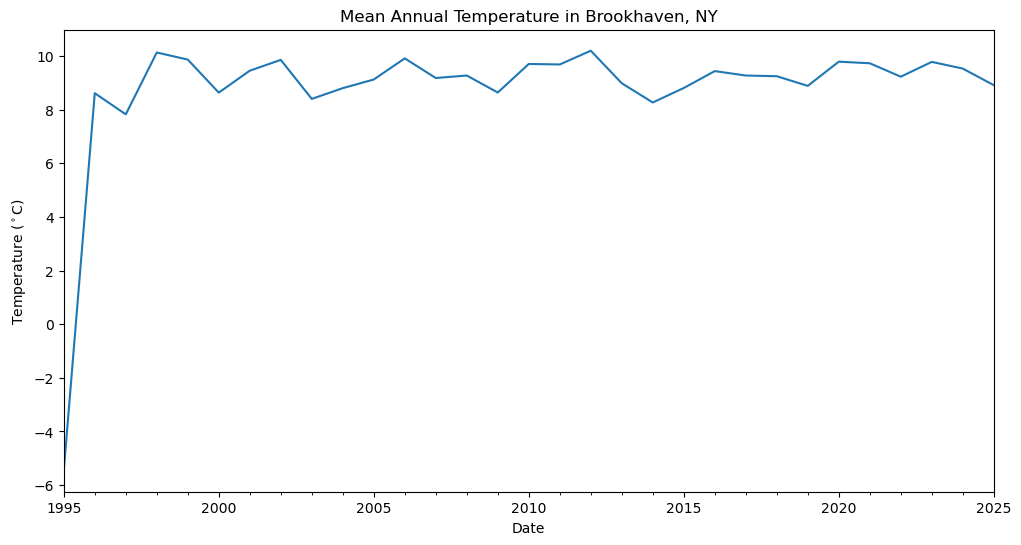

In [20]:
### Create a plot with the annual data
no_legend = ny_ann_temp_df.plot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in Brookhaven, NY',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)',
    figsize= (12,6))

### call the no legend object and tell it to remove the legend
no_legend.legend().remove()

In [19]:
### Create interactive plot

### Fixes issue that is preventing plot from being viewed
hvplot.extension("bokeh")

### plot the annual data interactively
ny_ann_temp_plot = ny_ann_temp_df.hvplot(
    y = 'temp_c',
    title = 'Mean Annual Temperature in Brookhaven, NY',
    xlabel = 'Year',
    ylabel = 'Temperature (degree C)'
)

### Show the plot
ny_ann_temp_plot



:Curve   [DATE]   (temp_c)

In [21]:
### Save the plot as an html
hv.save(ny_ann_temp_plot, 'annual_temp_brookhaven.html')

In [24]:
### subset data to just include celsius
ny_ann_temp_c_df = ny_ann_temp_df[['temp_c']]

### open dataframe
ny_ann_temp_c_df

,temp_c
DATE,
1995-01-01,-5.462963
1996-01-01,8.616704
1997-01-01,7.826752
1998-01-01,10.133517
1999-01-01,9.869102
2000-01-01,8.637894
2001-01-01,9.455307
2002-01-01,9.858025
2003-01-01,8.403558


In [25]:
### Steps to run a regression

### subset data to just include celsius
ny_ann_temp_c_df = ny_ann_temp_df[['temp_c']]

### Fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = ny_ann_temp_c_df.index.year.values.reshape(-1, 1)

### define dependent variable
dep_variable = ny_ann_temp_c_df

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: [0.09970587] degrees per year


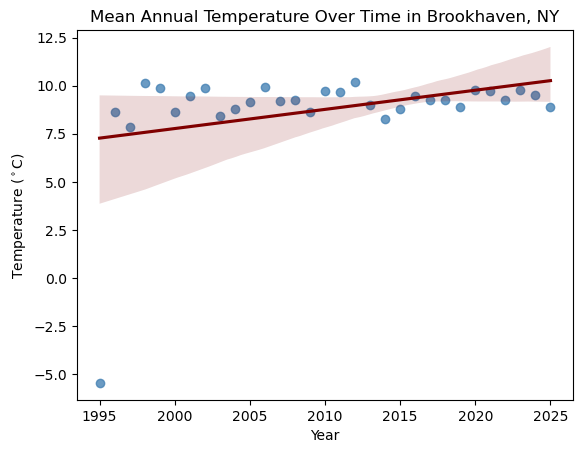

In [ ]:
### plot data
ax = sns.regplot(
    x = ny_ann_temp_c_df.index.year, 
    y = ny_ann_temp_c_df.temp_c,

    ### change the color of the data points
    color = 'steelblue',

    ### change the color of the trendline
    line_kws = {'color': 'maroon'},
)

### make labels
ax.set(
    title = 'Mean Annual Temperature Over Time in Brookhaven, NY',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/01-climate-fall/brookhaven_temp_trend.jpeg')

### plot it
plt.show()

In [31]:
### fit a linear model
lm_brookhaven_temp = sm.OLS(ny_ann_temp_c_df.index.year,
                            ny_ann_temp_c_df.temp_c)

### extract results
results_lm = lm_brookhaven_temp.fit()
results_lm

### see the model summary
print(results_lm.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.917
Model:                            OLS   Adj. R-squared (uncentered):              0.914
Method:                 Least Squares   F-statistic:                              329.8
Date:                Tue, 29 Sep 2026   Prob (F-statistic):                    9.86e-18
Time:                        00:42:46   Log-Likelihood:                         -241.26
No. Observations:                  31   AIC:                                      484.5
Df Residuals:                      30   BIC:                                      486.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------